<a href="https://colab.research.google.com/github/ArjunBhakta/Data-Science-Cohort-20/blob/main/Project_6_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Images – To Do List



Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition


Problem Definition

The goal of this project is to build a deep learning image classification model that can identify whether a new, unseen image is a cat or a dog. Using preprocessed image feature data and corresponding binary labels, the model will learn visual patterns from training examples and use those patterns to classify test images.

This is a supervised learning problem because the model is trained using labeled examples. It is also a binary classification problem because each image belongs to one of two classes: cat or dog.

* Load necessary packages.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Data Collection



* Load pickled data from X.pickle and y.pickle from the AWS S3 bucket.



In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [4]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [5]:
target = pd.read_pickle(target_url)
type(target)

list

In [6]:
image_array.shape

(24946, 100, 100, 1)

In [7]:
len(target)
print(target[0])

0


## Data Cleaning


* Scale the values in X so that they fall between 0 and 1 by dividing by 255.

The image pixel values originally ranged from 0 to 255. These values were normalized by dividing by 255, resulting in a range of 0 to 1. Normalization improves neural network training by making the input data more numerically stable, helping gradient descent converge faster, and ensuring the model processes all features on a consistent scale.



In [8]:
X = image_array / 255.0

In [9]:
print(X.min())
print(X.max())

0.0
1.0


## Exploratory Data Analysis



* Look at the shape of X and y. Ensure that X is 4 dimensional.

In [10]:
X.shape

(24946, 100, 100, 1)



* Plot a few ( >5 ) of the images in X using `plt.imshow()`.

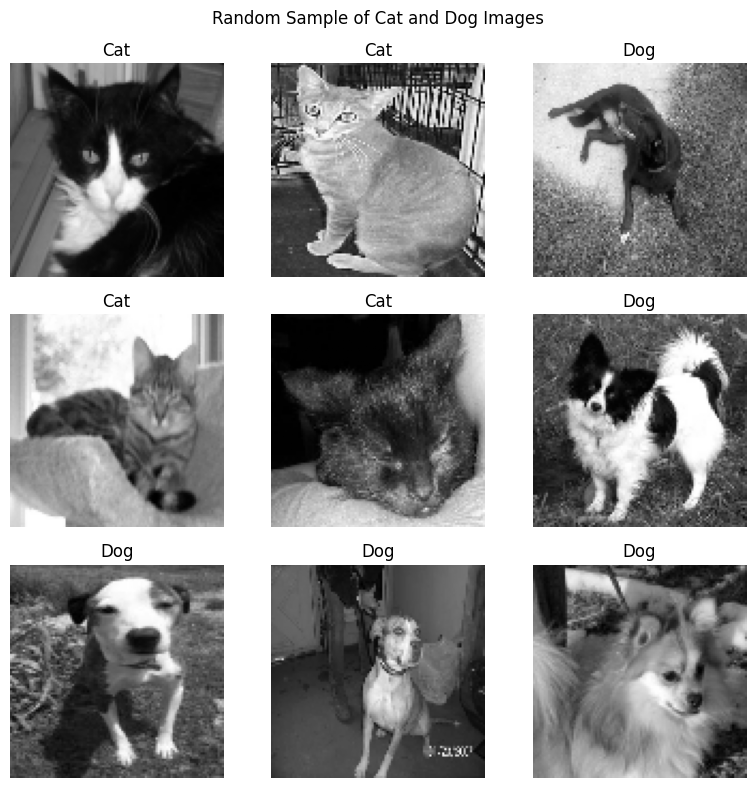

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax in axes.flat:
    idx = np.random.randint(len(X))

    ax.imshow(X[idx].squeeze(), cmap="gray")

    label = "Dog" if target[idx] == 0 else "Cat"
    ax.set_title(label)

    ax.axis("off")

plt.suptitle("Random Sample of Cat and Dog Images")
plt.tight_layout()
plt.show()

### Utilizing a smaller subset as well as a balanced subset

In [12]:
# Convert target to numpy array
y = np.array(target)

## Data Processing



* Split X and y into training and testing sets.



*  Build a convolutional neural network with the following:
  * Sequential layers
  * At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
  * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
  * A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.

* Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

* Fit your model using the training set.

* Evaluate your model using the testing set.

* Plot the distribution of probabilities for the testing set.

* Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )

* Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

* Use the neural network you created to predict whether the image is a dog or a cat.



In [28]:
y = np.array(target)

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (19956, 100, 100, 1)
X_test: (4990, 100, 100, 1)
y_train: (19956,)
y_test: (4990,)


In [29]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# model = Sequential([
#     Conv2D(32, (3,3), activation="relu", input_shape=(100,100,1)),
#     MaxPooling2D(pool_size=(2,2)),

#     Conv2D(64, (3,3), activation="relu"),
#     MaxPooling2D(pool_size=(2,2)),

#     Flatten(),
#     Dense(64, activation="relu"),
#     Dense(1, activation="sigmoid")
# ])

# model.compile(
#     optimizer="adam",
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )

# model.summary()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    # Data augmentation
    RandomFlip("horizontal", input_shape=(100, 100, 1)),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # Convolution block 1
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution block 2
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution block 3
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 100, 100, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731,329 (6.60 MB)

 Trainable params: 1,731,329 (6.60 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# history = model.fit(
#     X_train,
#     y_train,
#     epochs=10,
#     batch_size=32,
#     validation_split=0.2,
#     verbose=1
# )

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
499/499 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.5778 - loss: 0.6721 - val_accuracy: 0.6388 - val_loss: 0.6459
Epoch 2/25
499/499 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6625 - loss: 0.6168 - val_accuracy: 0.6899 - val_loss: 0.5784
Epoch 3/25
499/499 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6988 - loss: 0.5803 - val_accuracy: 0.7312 - val_loss: 0.5326
Epoch 4/25
499/499 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7281 - loss: 0.5433 - val_accuracy: 0.7618 - val_loss: 0.4986
Epoch 5/25
499/499 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7418 - loss: 0.5214 - val_accuracy: 0.7861 - val_loss: 0.4642
Epoch 6/25
499/499 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7675 - loss: 0.4895 - val_accuracy: 0.7788 - val_loss: 0.4650
Epoch 7/25
499/499 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7736 - loss: 0.4789 - val_accuracy: 0.8199 - val_loss: 0.4068
Epoch 8/25
499/499 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7838 - loss: 0.4590 - val_acc

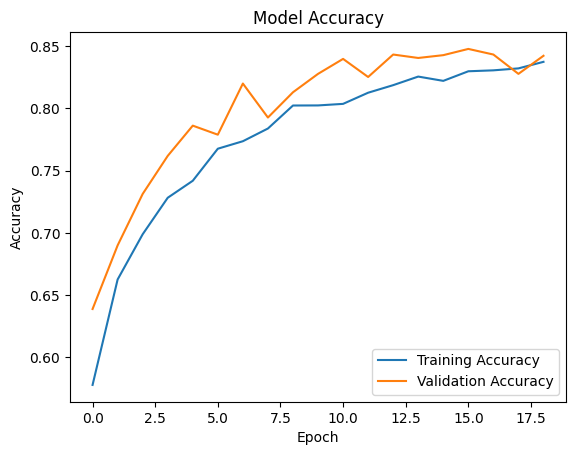

In [31]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

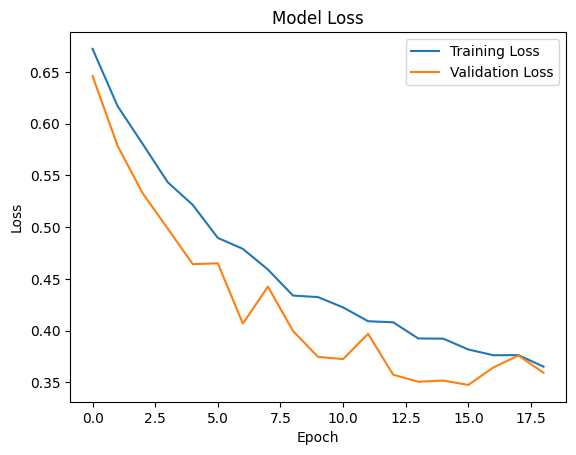

In [32]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

In [33]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8501 - loss: 0.3473
Test Loss: 0.3473159074783325
Test Accuracy: 0.8501002192497253


In [34]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


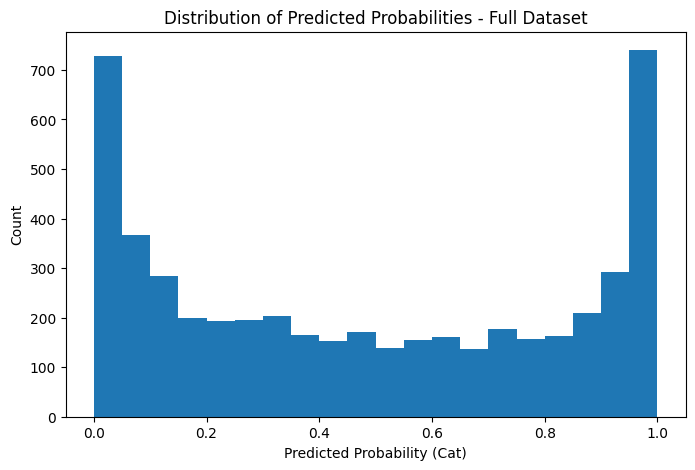

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y_pred_prob, bins=20)
plt.xlabel("Predicted Probability (Cat)")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities - Full Dataset")
plt.show()

In [36]:
misclassified_idx = np.where(y_pred != y_test)[0]

confidence = np.where(
    y_pred == 1,
    y_pred_prob.flatten(),
    1 - y_pred_prob.flatten()
)

print("Average confidence on mistakes:",
      confidence[misclassified_idx].mean())

Average confidence on mistakes: 0.6798743


In [37]:
import numpy as np

# Flatten probabilities
probs = y_pred_prob.flatten()

# Find mistakes
misclassified_idx = np.where(y_pred != y_test)[0]

# Confidence in the prediction made
confidence = np.where(
    y_pred == 1,
    probs,      # confidence of cat prediction
    1 - probs   # confidence of dog prediction
)

# Confidence for mistakes only
wrong_confidence = confidence[misclassified_idx]

# Sort highest confidence mistakes first
top_wrong = misclassified_idx[np.argsort(wrong_confidence)[::-1]]

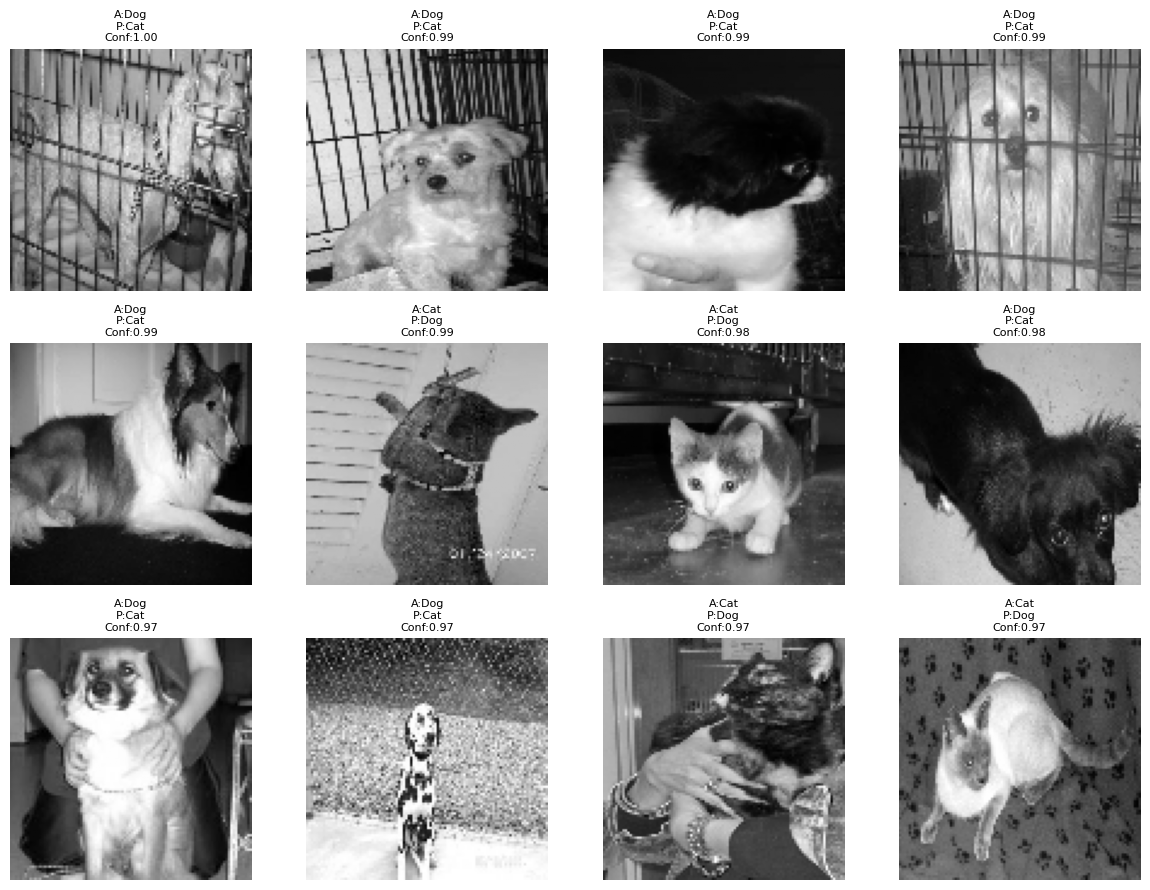

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, idx in zip(axes.flat, top_wrong[:12]):

    ax.imshow(X_test[idx].squeeze(), cmap="gray")

    actual = "Dog" if y_test[idx] == 0 else "Cat"
    pred = "Dog" if y_pred[idx] == 0 else "Cat"

    ax.set_title(
        f"A:{actual}\nP:{pred}\nConf:{confidence[idx]:.2f}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [39]:
dog_errors = np.sum((y_test == 0) & (y_pred != y_test))
cat_errors = np.sum((y_test == 1) & (y_pred != y_test))

print("Dog errors:", dog_errors)
print("Cat errors:", cat_errors)

Dog errors: 291
Cat errors: 457


In [40]:
brightness = X_test.mean(axis=(1,2,3))

In [41]:
correct = brightness[y_pred == y_test]
wrong = brightness[y_pred != y_test]

print("Correct avg brightness:", correct.mean())
print("Wrong avg brightness:", wrong.mean())

Correct avg brightness: 0.4631781572695085
Wrong avg brightness: 0.4627536264024326


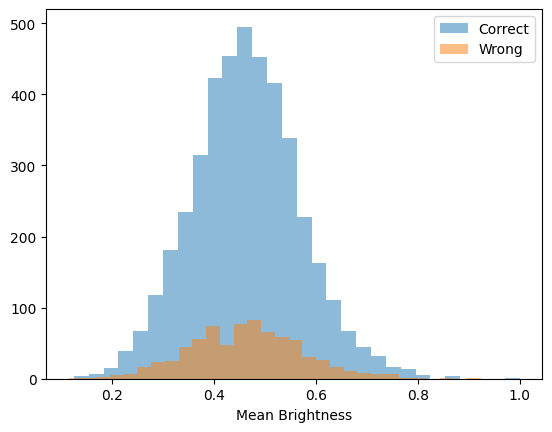

In [42]:
plt.hist(correct, bins=30, alpha=.5, label="Correct")

plt.hist(wrong, bins=30, alpha=.5, label="Wrong")

plt.legend()

plt.xlabel("Mean Brightness")

plt.show()

In [43]:
contrast = X_test.std(axis=(1,2,3))
contrast

array([0.20830446, 0.15962099, 0.27292812, ..., 0.27713878, 0.17050904,
       0.21400675])

In [44]:
correct_idx = np.where(y_pred == y_test)[0]

print("Correct confidence:",
      confidence[correct_idx].mean())

print("Wrong confidence:",
      confidence[misclassified_idx].mean())

Correct confidence: 0.8467089
Wrong confidence: 0.6798743


In [45]:
high_conf_wrong = np.sum(confidence[misclassified_idx] > 0.9)

print(high_conf_wrong)
print(high_conf_wrong / len(misclassified_idx))

50
0.06684491978609626


## Communication of Results


In this project, a convolutional neural network (CNN) was developed to classify images as either cats or dogs. The image data was normalized, explored visually, and split into training and testing datasets before being used to train the model.

An initial CNN architecture achieved approximately 77.6% test accuracy. The model was then improved by adding data augmentation, an additional convolutional layer, dropout regularization, and early stopping. These changes increased the test accuracy to approximately 85%, demonstrating the importance of architecture design and regularization techniques in deep learning.

Training and validation accuracy curves showed similar performance throughout training, while both loss curves steadily decreased. This suggests that the model generalized well and did not exhibit significant overfitting. Analysis of prediction probabilities also showed that the model was generally confident in its classifications, while maintaining lower confidence on many of its incorrect predictions.